In [1]:
import pandas as pd
import numpy as np
import joblib
from tqdm.auto import tqdm

# Sentence Transformers để tạo embeddings
from sentence_transformers import SentenceTransformer

# Scikit-learn cho mô hình và đánh giá
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, make_scorer


In [2]:
try:
    df = pd.read_csv('data/mail_data.csv', nrows=9000)
    print("Tải dữ liệu thành công!")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'data/raw_data.csv'.")
    print("Hãy chắc chắn rằng bạn đã tạo thư mục 'data' và đặt tệp dữ liệu vào đó.")

df.head()

Tải dữ liệu thành công!


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Ánh xạ 'ham' -> 0 và 'spam' -> 1
df['label'] = df['Category'].map({'ham': 0, 'spam': 1})

# Xóa các dòng có giá trị thiếu (nếu có)
df.dropna(inplace=True)

# Chọn các cột cần thiết
data = df[['Message', 'label']]

print("Dữ liệu sau khi xử lý:")
data.head()

Dữ liệu sau khi xử lý:


,Message,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [4]:
# lây embeddings từ file đã lưu
embeddings = joblib.load('data/embeddings.pkl')
# Gán X (features) và y (target)
X = embeddings
y = data['label'].values

In [18]:
df = pd.read_csv('data/email_spam.csv', nrows=9000)
embeddings = joblib.load('data/email_spam.pkl')
# Gán X (features) và y (target)
X = embeddings
df['label'] = df['type'].map({'not spam': 0, 'spam': 1})
y = df['label'].values

In [19]:
print("Kích thước của X:", X.shape)
print("Kích thước của y:", y.shape)

Kích thước của X: (84, 384)
Kích thước của y: (84,)


In [ ]:
# Chia dữ liệu thành tập train và test

train set: 5259 samples
test set: 1315 samples


In [12]:
model_path = 'checkpoints/logistic_regression_best.pkl'
loaded_model = joblib.load(model_path)


Độ chính xác trên tập kiểm tra: 0.4643

Confusion Matrix:
[[23 35]
 [10 16]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.70      0.40      0.51        58
        Spam       0.31      0.62      0.42        26

    accuracy                           0.46        84
   macro avg       0.51      0.51      0.46        84
weighted avg       0.58      0.46      0.48        84



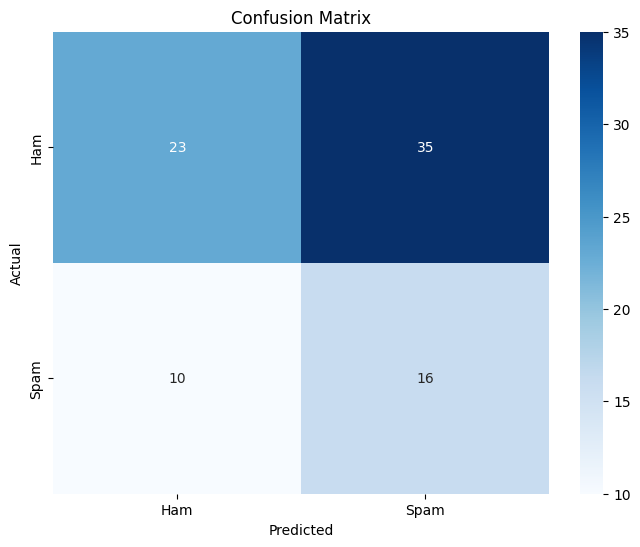

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
# Dự đoán trên tập test
y_pred = loaded_model.predict(X)

# Tính toán các chỉ số đánh giá
accuracy = accuracy_score(y, y_pred)
conf_matrix = confusion_matrix(y, y_pred)
class_report = classification_report(y, y_pred, target_names=['Ham', 'Spam'])

print(f"Độ chính xác trên tập kiểm tra: {accuracy:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()